# Coursework Set Week 6

**Common remarks**:

* Deadline: Sunday at 23:59h for the week of this task
* <font color='red'>Keep all the information in this template unaltered!</font>

**Please fill in the following fields:**

* Name: Marit Bakelaar
* Username: mdbakelaar
* Student number: S6360912
* Group (AS1, etc.): As4

-----

In [1]:
totalpoints = currentpoints = 0

### Exploring a HI data cube (7 pt) <font color='red'><b>COURSEWORK</b></font>
   
* Download FITS image [ngc6946.fits](https://www.astro.rug.nl/intranet/courses/PROGNUMNEW/latest/DATA/ngc6946.fits)
* Create a mosaic with 5 rows and 10 columns of channel maps for the Z indices ``range(1, 101, 2)``
* Remove axis labeling with Axes methods ``set_xticklabels([])`` and ``set_yticklabels([])``.
* If you add two channel maps you get a new map where each pixel is the sum of the two maps. If you add all channel maps (not the noisy ones), you get a so called *total HI* map.

    * Select a suitable range of channel maps and sum them to get a total HI map. Make a plot of this map
    * Label the axes with the header values of ``CTYPE1`` and ``CTYPE2``.
    * Make a locatable colorbar and label its Y axis with the header value of ``BUNIT``. 
        
* A *position velocity* (PV) map is a slice through the data at one fixed spatial position. 
   It tells you something about how the velocities in a galaxy behave as function of position 
   and one fixed position.   
   In NumPy jargon a PV map can be an YZ slice or a XZ slice. 

    * Plot a PV map for a fixed Right Ascension (R.A.) with index 50.
    * Plot a vertical line at Dec. with index 40.
    * Label the axes with the header values of ``CTYPE2`` and ``CTYPE3``. <br>&nbsp;</br>
        
* A *global HI spectral profile* is a slice in along the spectral axis at a fixed Right Ascension and Declination.
   It is a 1D curve with intensities as function of frequency (or velocity). It shows you at which 
   velocity most of the gas is rotating in a galaxy given a position in R.A. and Dec.

    * Plot a global profile at R.A. with index 50 and Dec. with index 40.
    * Label the plot axes with the header values of ``CTYPE3`` and ``BUNIT``. <br>&nbsp;</br>

* What is the relation between this profile and the vertical line in the previous plot of the PV diagram?   

**Answers**:

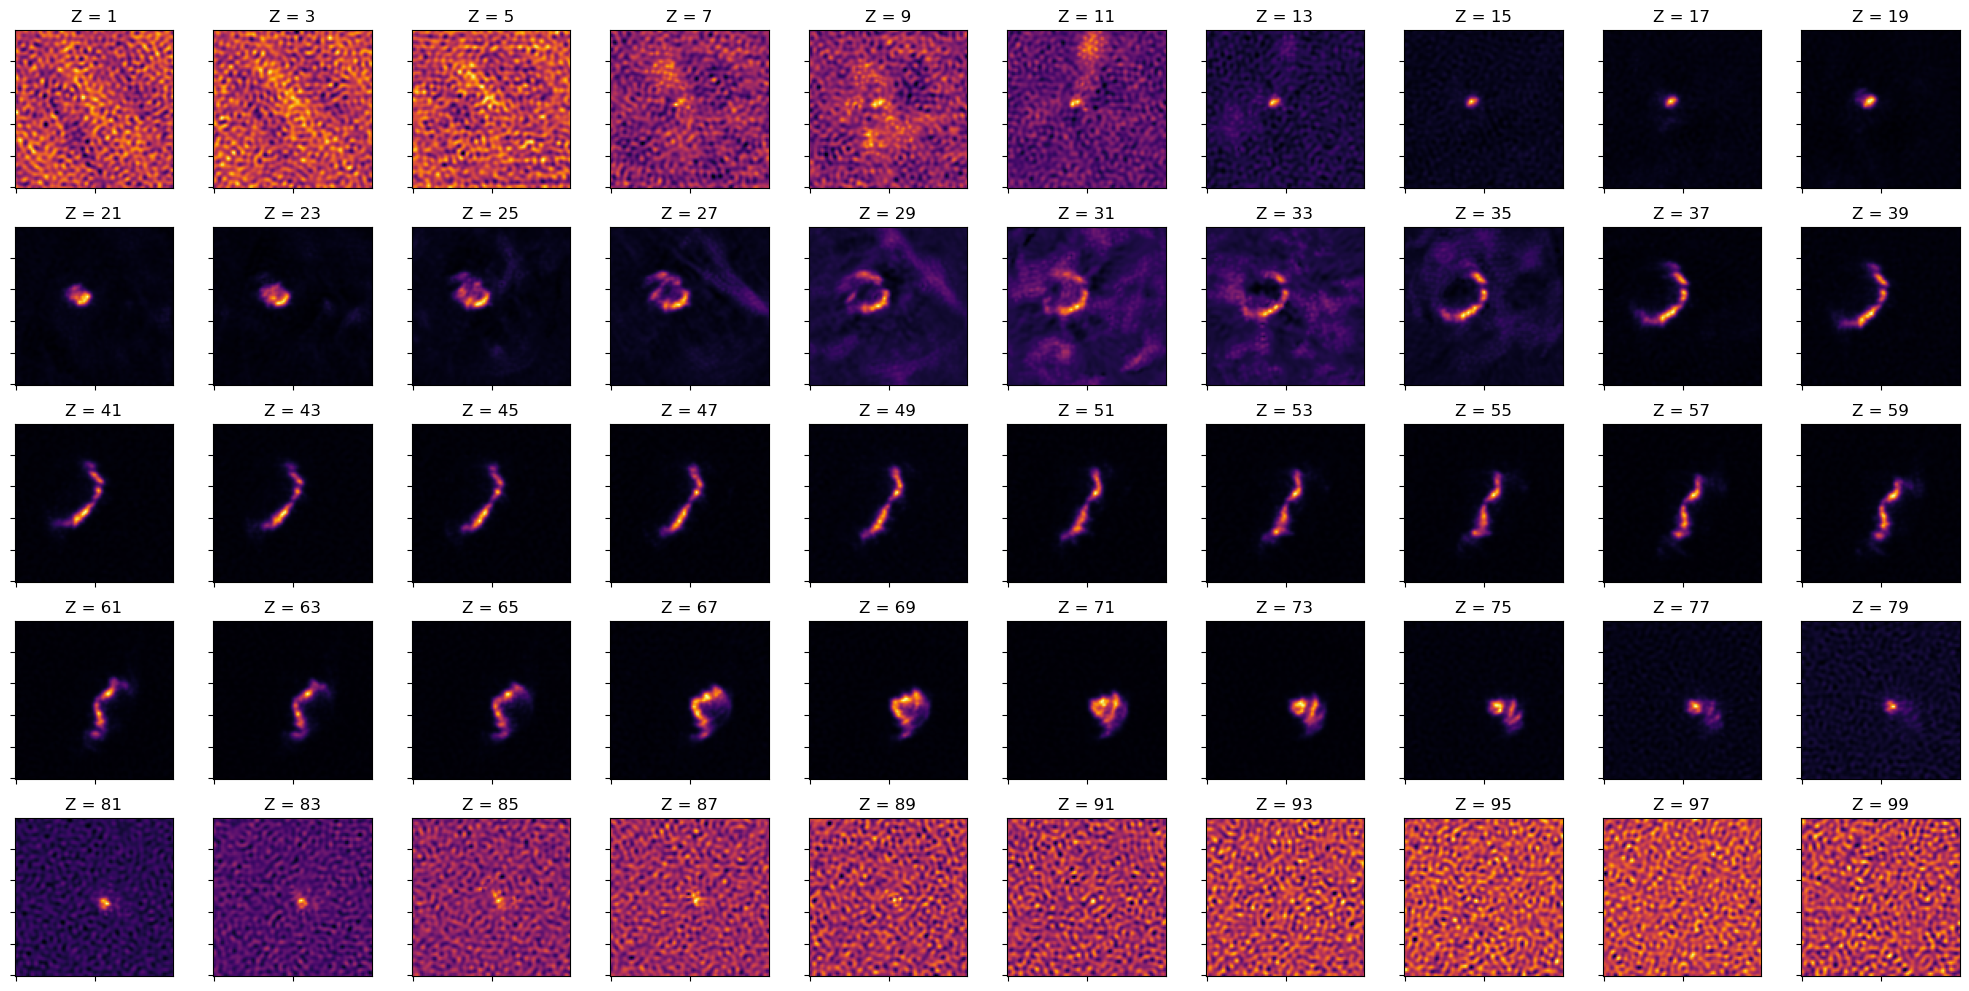

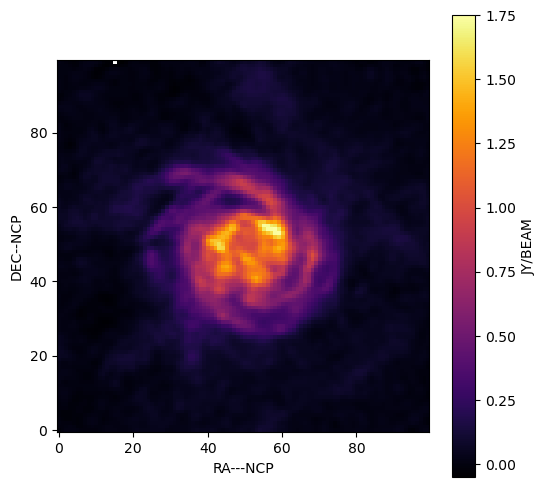

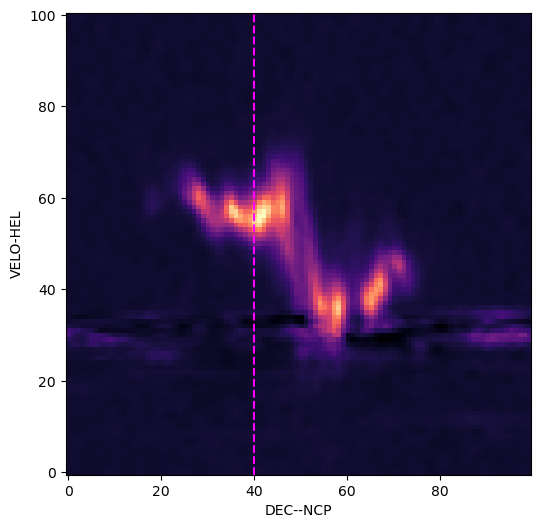

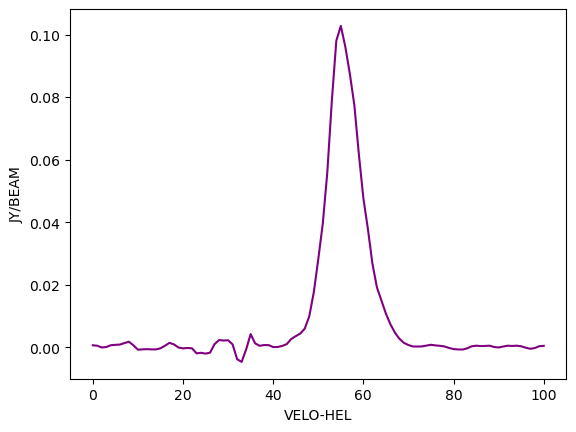

In [2]:
import matplotlib.pyplot as plt
import numpy as np
from astropy.io import fits

#opening the fits file and getting its data
hdulist = fits.open("ngc6946.fits")
data = hdulist[0].data

#creating a range to later use it to take slices from our data
indices = list(range(1, 101, 2))  # 50 channels

#setting up the figure of 5 rows and 10 cplumns
fig, axes = plt.subplots(nrows=5, ncols=10, figsize=(20, 10))

#flattening to work with it easier
axes = axes.flatten()


for ax, i in zip(axes, indices):
    #showing every other slice
    ax.imshow(data[i], origin='lower', cmap = 'inferno')

    #deleting the ticklabels so the total figure is easier to look at
    ax.set_xticklabels([])
    ax.set_yticklabels([])

    #setting a title for each individual image
    ax.set_title(f"Z = {i}")

#ensuring they're plotted nicely together
plt.tight_layout()
plt.show()


header = hdulist[0].header

#creating a range of all the images with the least amount of background noise
rangechannels = range(17, 79)

#creating the HI map using the range
HI_map = np.sum(data[rangechannels, :, :], axis=0)

#creating a figure to show the combined slices
fig, ax = plt.subplots(figsize=(6, 6))
im = ax.imshow(HI_map, origin='lower', cmap='inferno')

#setting the axis labels
ax.set_xlabel(header['CTYPE1'])
ax.set_ylabel(header['CTYPE2'])

#adding a colorbar with a label
cbar = plt.colorbar(im, ax=ax)
cbar.set_label(header['BUNIT'])

#show the plot
plt.show()


#fixing RA so we are working with only 2 variables and thus a 2D slice of the data
PV_map = data[:, :, 50]

#plotting the 2D slice as an image
fig, ax = plt.subplots(figsize=(6, 6))
im = ax.imshow(PV_map, origin='lower', aspect='auto', cmap='magma')

#making a vertical line at Dec. with index 40
ax.axvline(x=40, color='magenta', linestyle='--')

#adding labels to the image
ax.set_xlabel(header['CTYPE2'])  
ax.set_ylabel(header['CTYPE3'])  

#showing the plot
plt.show()


#taking a slice with all the different velocities and a set RA and dec
spectrum = data[:, 40, 50]

#setting up the figure and plotting the intensity against the velocity
fig, ax = plt.subplots()
ax.plot(spectrum, color='purple')

#setting the labels
ax.set_xlabel(header['CTYPE3'])
ax.set_ylabel(header['BUNIT'])

#showing the plot
plt.show()

In [3]:
# Leave unaltered
totalpoints += 7
currentpoints += 0.0

### Galaxy Colour (5 pt) <font color='red'><b>COURSEWORK</b></font>
   
Download [SDSS_DR17_galaxies.fits](https://brightspace.rug.nl/content/enforced/457626-WBAS018-05.2025-2026.1/SDSS_DR17_galaxies.fits), which contains apparent magnitude in ``u, g, r, i, z`` five SDSS broad-band filters.

* Create a Pandas DataFrame from the FITS table.
* Filter out any data with negative values.
* Calculate every combination of colours from each broad band filter, e.g. u-g, u-r, u-i, u-z, g-r, ......
* Calculate the mean and standard deviation of the each colour.
* Use Object-Oriented Plotting to create a corner plot using derived colours.
* Set the xlim and ylim to be within three standard deviation.
* Add title for each histogram with information of the mean and standard deviation of each colour in the format of $\mu\pm\sigma$
 (to one decimal place).

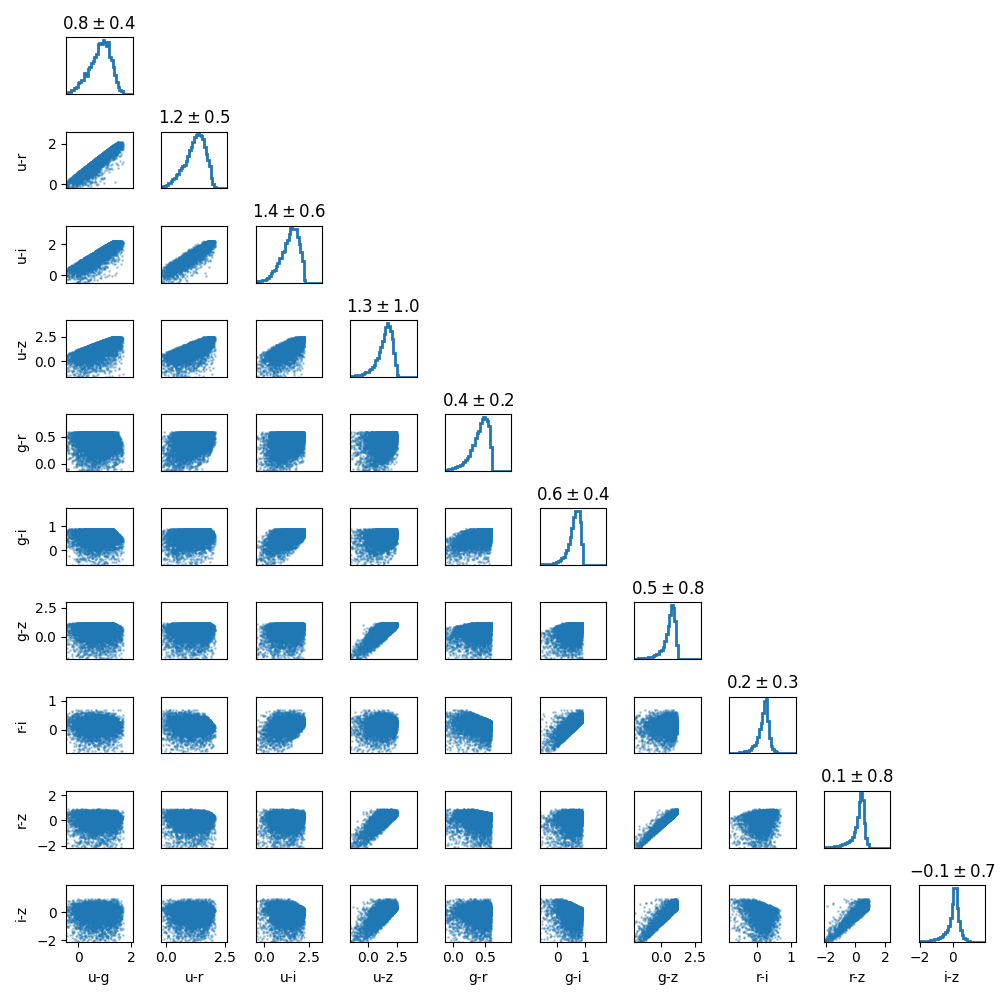
   
**Plot and answer**:

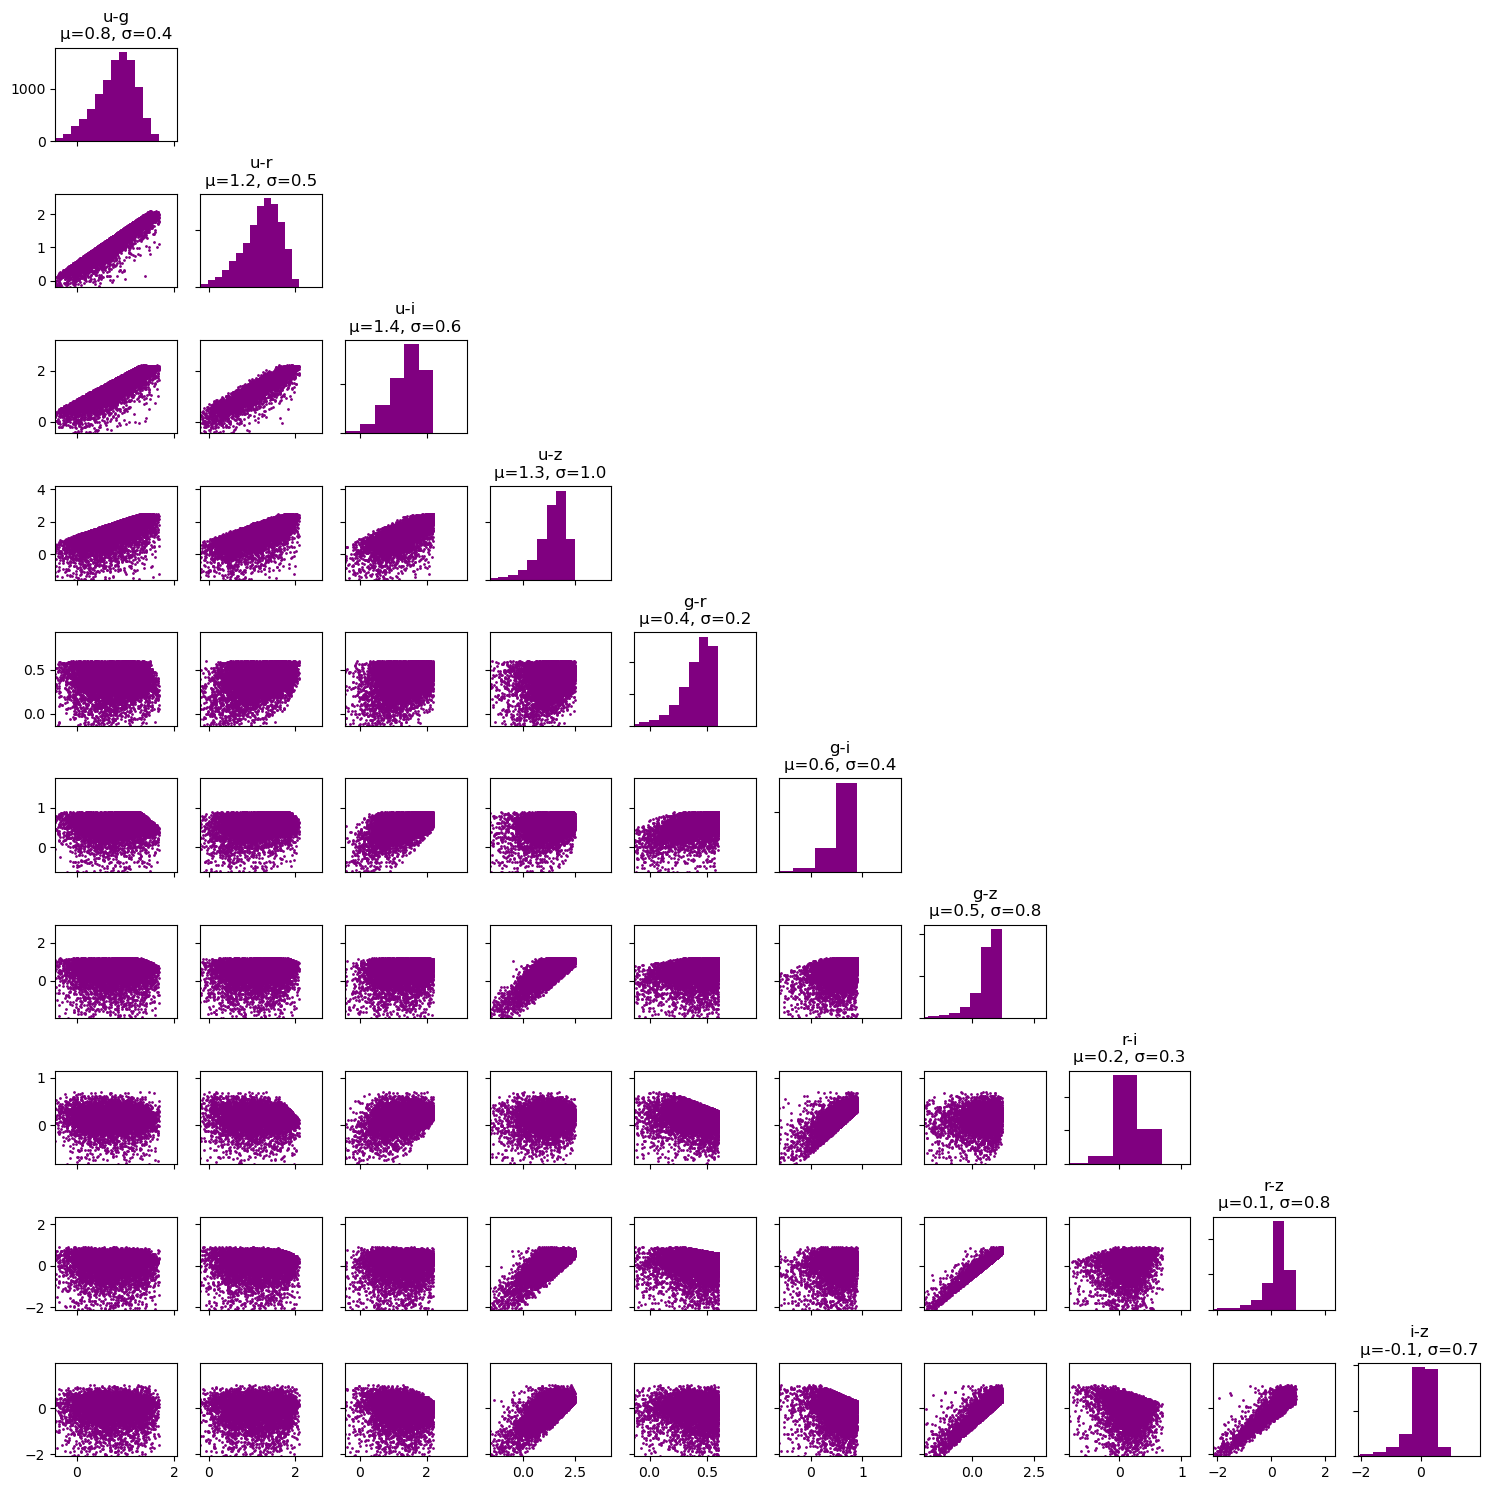

In [4]:
import matplotlib.pyplot as plt
import numpy as np
from astropy.io import fits
import pandas as pd

#opening the file and getting the data and making a pandas dataframe
hdulist = fits.open("SDSS_DR17_galaxies.fits")
header = hdulist[0].header
data = hdulist[1].data
gal = pd.DataFrame(data)

#filtering out the negative values
pos = gal[(gal >= 0).all(axis=1)]

#getting all the different colour combinations
colours = {
    "u-g": pos['u'] - pos['g'],
    "u-r": pos['u'] - pos['r'],
    "u-i": pos['u'] - pos['i'],
    "u-z": pos['u'] - pos['z'],
    "g-r": pos['g'] - pos['r'],
    "g-i": pos['g'] - pos['i'],
    "g-z": pos['g'] - pos['z'],
    "r-i": pos['r'] - pos['i'],
    "r-z": pos['r'] - pos['z'],
    "i-z": pos['i'] - pos['z'],
}


#getting the means and standard deviations of all the colour combinations 
col_df = pd.DataFrame(colours)
means = col_df.mean()
stdevs = col_df.std()

cols = col_df.columns
n = len(cols)

#setting up the figure
fig, axes = plt.subplots(n, n, figsize=(15, 15))

#making a for loop that will give us the correct graphs
for i in range(n):
    for j in range(n):
        ax = axes[i, j]

        #to make sure it will be of triangular form
        if i < j:
            ax.axis('off')
            continue
        
        elif i == j:
            #making the histograms
            data = col_df[cols[i]]
            mean = means[cols[i]]
            stdev = stdevs[cols[i]]
            
            ax.hist(data, bins=30, color = 'purple') #always adding a pretty color :D
            ax.set_xlim(mean - 3*stdev, mean + 3*stdev)
            ax.set_title(f"{cols[i]}\nμ={mean:.1f}, σ={stdev:.1f}")
            
        
        else:
            #making the scatter plots
            x = col_df[cols[j]] 
            y = col_df[cols[i]]
            
            ax.scatter(x, y, s=1, color = 'purple') #always adding a pretty color :D
            ax.set_xlim(means[cols[j]] - 3*stdevs[cols[j]],
                        means[cols[j]] + 3*stdevs[cols[j]])
            
            ax.set_ylim(means[cols[i]] - 3*stdevs[cols[i]],
                        means[cols[i]] + 3*stdevs[cols[i]])
        
        #making the figrue neat looking
        if i < n - 1:
            ax.set_xticklabels([])
        if j > 0:
            ax.set_yticklabels([])

plt.tight_layout()
plt.show()

In [5]:
# Leave unaltered
totalpoints += 5
currentpoints += 0.0

### Astroquery: retrieving SDSS image and spectra (5 pt) <font color='red'><b>COURSEWORK</b></font>

Spiral galaxy M77 (NGC 1068) is a bright galaxy known for hosting an active galactic nucleus (AGN). With Astropy package, we construct M77's coordinate using the code below.

```python
from astropy import coordinates as coords

# Coordinates of M77
ra = 40.6696  # degrees
dec = -0.0133  # degrees
pos = coords.SkyCoord(ra, dec, unit="deg", frame="icrs")
```

* Use ``astroquery`` ([search regions](https://astroquery.readthedocs.io/en/latest/sdss/sdss.html#searching-regions-and-multiple-objects)) on the ``pos``, containing RA and DEC of this galaxy, to retrieve its SDSS spectrum using ``get_spectra()``. The search radius sets as ``10 arcsec`` for searching.
* The return object of ``get_spectra()`` is a list of [HDUList](https://docs.astropy.org/en/stable/io/fits/api/hdulists.html#astropy.io.fits.HDUList) objects.
* Retrieve flux and wavelengths using columns ``flux`` and ``loglam``. Note that the wavelength is in logarithmic value, you need to convert it back to a linear scale.
* The redshift of M77 is approximately ``z~0.0038``. Calculating the rest-frame wavelengths.
* Use Object-Oriented Plotting to plot:
    * a rest-frame spectrum which corrects the redshift effect (top)
    * a zoom-in spectrum at wavelength between 6450 and 6650 angstrom (bottom)
* Draw vertical lines for H$\alpha$ lines in both frames. Label them and show with legend.
* Draw vertical lines indicating approximately where the peak of the flux is, which in fact should be the H$\alpha$ line.
* An example plot is shown below.
* Calculating the velocity indicated by the difference between the two wavelengths.
* Share your thought using a markdown on what might be causing this offset. This question will not be graded, and meant to train a bit your scientific thinking. Feel free to express any thought.

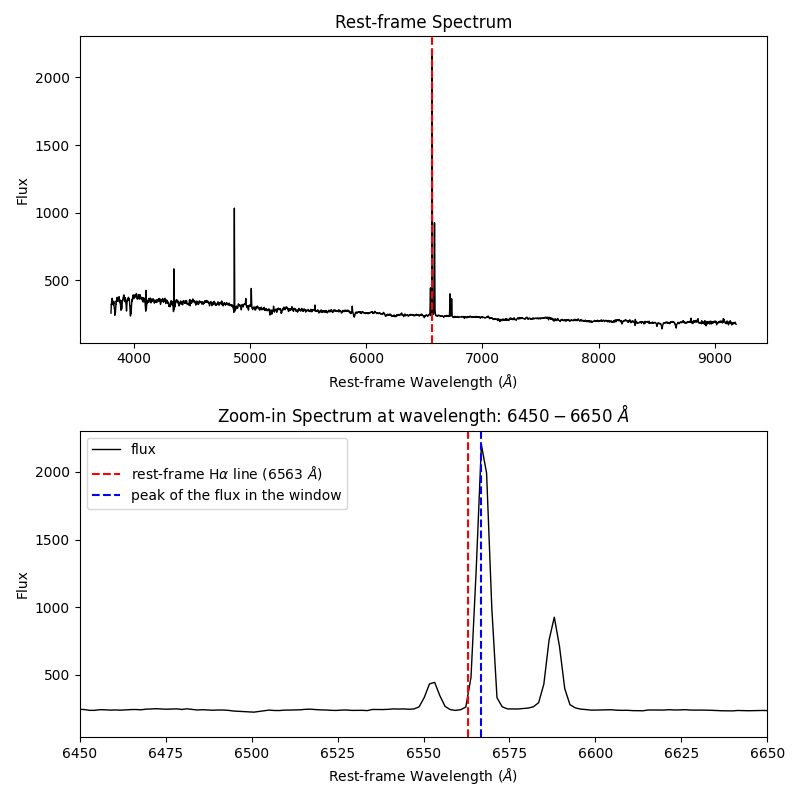

In [6]:
pip install astroquery

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


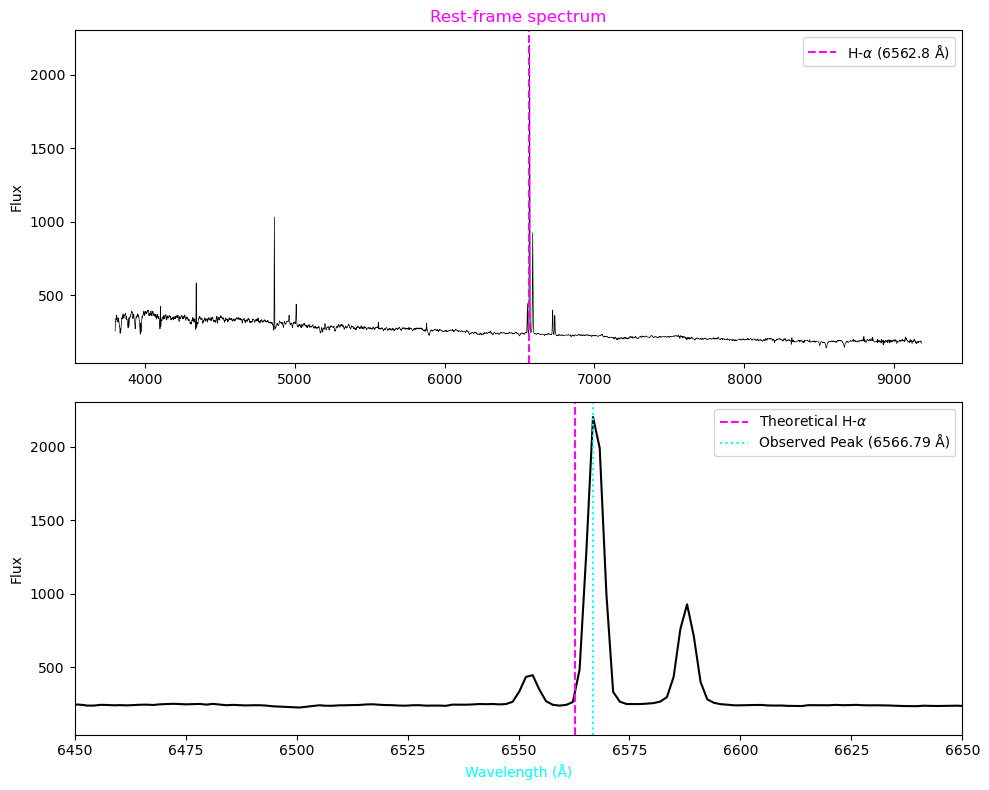

the velocity is 182.0531463623047


In [7]:
import matplotlib.pyplot as plt
import numpy as np
from astroquery.sdss import SDSS
from astropy import coordinates as coords
from scipy.constants import c

#The gvien values
ra = 40.6696
dec = -0.0133
z = 0.0038
Halpha = 6562.8
pos = coords.SkyCoord(ra, dec, unit="deg", frame="icrs")

#getting the spectra using astroquery
xid = SDSS.query_region(pos, radius='10 arcsec', spectro=True)
sp = SDSS.get_spectra(matches=xid)

#getting the data 
hdulist = sp[0]
data = hdulist[1].data

#getting the flux in the data
flux = data['flux']
#retrieving wavelength and making it in linear scale not log
wavelength_obs = 10**data['loglam']

#calculating the rest wavelength with the redshift and observed wavelenght
wavelength_rest = wavelength_obs / (1 + z)

#getting the peak wavelenght
peak = wavelength_rest[np.argmax(flux)]


#setting up the figure
fig, ax = plt.subplots(2, 1, figsize=(10, 8), sharex=False)

#plotting the first plot
ax[0].plot(wavelength_rest, flux, color='black', lw=0.5)
ax[0].axvline(Halpha, color = 'magenta', linestyle = '--', label = r'H-$\alpha$ (6562.8 Å)')
ax[0].set_title("Rest-frame spectrum", color = 'magenta')
ax[0].set_ylabel("Flux")
ax[0].legend()

#plotting the second plot and adding color to it :D
ax[1].plot(wavelength_rest, flux, color = 'black')
ax[1].set_xlim(6450, 6650)
ax[1].axvline(Halpha, color = 'magenta', linestyle = '--', label = r'Theoretical H-$\alpha$')
ax[1].axvline(peak, color = 'cyan', linestyle = ':', label = f'Observed Peak ({peak:.2f} Å)')
ax[1].set_xlabel("Wavelength (Å)", color = 'cyan')
ax[1].set_ylabel("Flux")
ax[1].legend()

plt.tight_layout()
plt.show()

#calculate the velocity with c in km/s not m/s
velocity = ((peak - Halpha) / Halpha) * c / 1000
print(f'the velocity is {velocity}')

In [8]:
# Leave unaltered
totalpoints += 5
currentpoints += 0.0

### Comparing an image in different color scales (stretches) (4pt) <font color='red'><b>COURSEWORK</b></font>

Given is the Blaauw observatory FITS file
[20210422_Li_.00000066.FIT](https://www.astro.rug.nl/intranet/courses/PROGNUMNEW/latest/DATA/20210422_Li_.00000066.FIT)

Use the `imdisplay()` function from the notebook *The art of plotting an image* to make a mosaic with this image using all the different scales (stretches) available to that function. 

* Add a proper docstring to the function.
* Show the used scale in the title of the plot. (hints: tight_layout, fontsize).
* Also include the image without scaling as the first plot in the mosaic.

**Answer**:

/opt/anaconda-hub/lib/python3.13/site-packages/astropy/visualization/stretch.py:543: RuntimeWarning: overflow encountered in sinh
  np.sinh(values, out=values)
/opt/anaconda-hub/lib/python3.13/site-packages/matplotlib/colors.py:777: RuntimeWarning: overflow encountered in multiply
  xa *= self.N


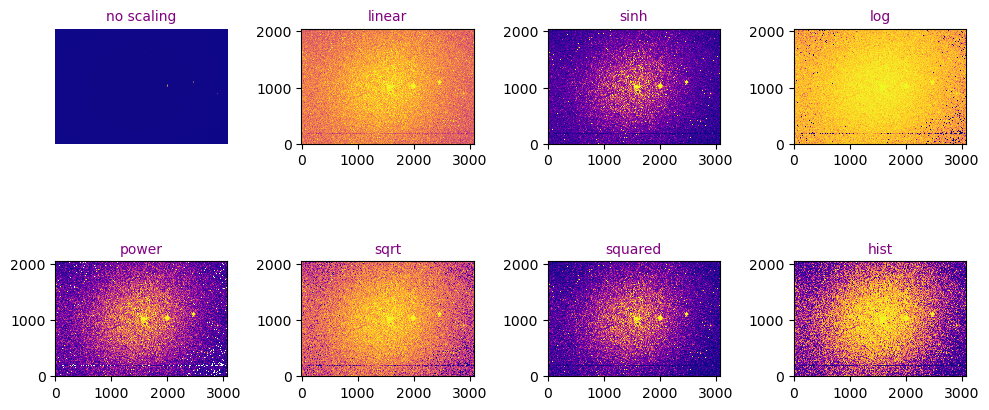

In [9]:
import matplotlib.pyplot as plt
import numpy as np
from astropy.io import fits
from astropy.visualization import ImageNormalize
from astropy.visualization import SinhStretch, AsymmetricPercentileInterval, LinearStretch,\
                                  LogStretch, PowerStretch, SqrtStretch, SquaredStretch,\
                                  HistEqStretch, ZScaleInterval


#copypaste this from the notebook 42: the art of plotting an image
def imdisplay(data,
              ax,
              vmin=None, vmax=None,
              percentlow=1, percenthigh=99,
              zscale=False,
              scale='linear',
              power=1.5,
              #making the plots a prettier colour :D
              cmap='plasma',
              **kwargs):
    if zscale:
        # Always overwrite vmin and vmax
        interval = ZScaleInterval()
        vmin, vmax = interval.get_limits(data)
    if vmin is None or vmax is None:
        interval = AsymmetricPercentileInterval(percentlow, percenthigh)
        vmin2, vmax2 = interval.get_limits(data)
        if vmin is None:
            vmin = vmin2
        if vmax is None:
            vmax = vmax2

    if scale == 'linear':
        stretch = LinearStretch(slope=0.5, intercept=0.5)
    if scale == 'sinh':
        stretch = SinhStretch()
    if scale == 'log':
        stretch = LogStretch()
    if scale == 'power':
        stretch = PowerStretch(power)
    if scale == 'sqrt':
        stretch = SqrtStretch()
    if scale == 'squared':
        stretch = SquaredStretch()
    if scale == 'hist':
        stretch = HistEqStretch(data)  # Needs argument data and data min, max for vmin, vmax
        vmin = data.min(); vmax = data.max()

    norm = ImageNormalize(vmin=vmin, vmax=vmax, stretch=stretch)
    return ax.imshow(data, interpolation='none', origin='lower', norm=norm, cmap=cmap, **kwargs)

#opening the file and getting the data
hdulist = fits.open("20210422_Li_.00000066.FIT")
data = hdulist[0].data

#setting up the total figure in a 2x4 so all 8 plots are on there and so we do not have an extra one
fig, ax = plt.subplots(2, 4, figsize=(10, 5))
ax = ax.flatten() 

#plotting the first one without a scale, and ofcourse making it a prettier colour
ax[0].imshow(data, origin='lower', cmap='plasma')
ax[0].set_title('no scaling', fontsize = 10, color = 'purple')
ax[0].axis('off')

#making a list of all the scales
scales = ['linear', 'sinh', 'log', 'power', 'sqrt', 'squared', 'hist']

#going through all the different scales and plotting them
for i, scale in enumerate(scales, start=1):
    imdisplay(data, ax=ax[i], scale=scale)  
    ax[i].set_title(scale, fontsize = 10, color = 'purple')



plt.tight_layout()
plt.show()

In [10]:
# Leave unaltered
totalpoints += 4
currentpoints += 0.0

### Image stacking optical data (6pt) <font color='red'><b>COURSEWORK</b></font>

Select one of the suitable observations from the next table or
find one yourself in the
[Blaauw Observatory Overview](https://www.astro.rug.nl/intranet/sterrenwacht/files.py)

* Following the stacking procedure in the notebook about image stacking for the data you selected. Show the result.
* Align the images and repeat the stacking procedure. Show the result.
* Remove all unnecessary code and markdown text.
* Include code and result in your report.

| nr | Folder on data server |
| :---  | :---: |
| 2  | ``/net/dataserver3/data/users/sterrenwacht/images/210418/STL-6303E/i/`` |
| 3  | ``/net/dataserver3/data/users/sterrenwacht/images/190515/STL-6303E/i/`` |
| 4  | ``/net/dataserver3/data/users/sterrenwacht/images/190428/STL-6303E/i/`` |
| 5  | ``/net/dataserver3/data/users/sterrenwacht/images/190419/STL-6303E/i/`` |
| 6  | ``/net/dataserver3/data/users/sterrenwacht/images/180504/STL-6303E/i/`` |
| 7  | ``/net/dataserver3/data/users/sterrenwacht/images/160913/STL-6303E/i/`` |
| 8  | ``/net/dataserver3/data/users/sterrenwacht/images/140912/STL-6303E/i/`` |
| 9  | ``/net/dataserver3/data/users/sterrenwacht/images/131001/STL-6303E/i/`` |
| 10 | ``/net/dataserver3/data/users/sterrenwacht/images/101212/STL-6303E/i/`` |

**Code and plot**:

180504_Li_00000059.fits
180504_Li_00000081.fits
180504_Li_00000068.fits
180504_Li_00000070.fits
180504_Li_00000085.fits


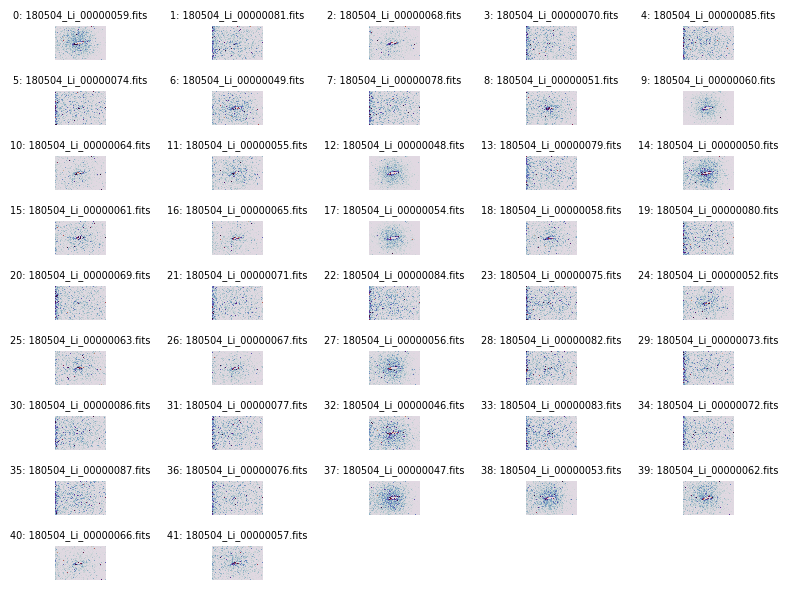

In [11]:
from pathlib import Path
from matplotlib.pyplot import figure, show
from astropy.io import fits
from math import ceil
from astropy.visualization import ImageNormalize
from astropy.visualization import SinhStretch, AsymmetricPercentileInterval, LinearStretch,\
                                  LogStretch, PowerStretch, SqrtStretch, SquaredStretch,\
                                  HistEqStretch, ZScaleInterval
#step 1 from the notebook
datadir = "/net/dataserver3/data/users/sterrenwacht/images/180504/STL-6303E/i/"  # Replace by your own data folder (not in home!)
excludes = ['BIAS', 'FLAT', 'DARK']  # Exclude these images if these are opart of the file name

path = Path(datadir)
filepaths = []
for filepath in path.iterdir():
    if filepath.suffix.lower() in ['.fits', '.fit', '.fts']:
        if not any(ext in filepath.name for ext in excludes):
            filepaths.append(filepath)

# Print first 5 file names
for f in filepaths[:5]:
    print(f.name)

#step 2 from the notebook
def imdisplay(data,
              ax,
              vmin=None, vmax=None,
              percentlow=1, percenthigh=99,
              zscale=False,
              scale='linear',
              power=1.5,
              cmap='gray',
              **kwargs):
    if zscale:
        # Always overwrite vmin and vmax
        interval = ZScaleInterval()
        vmin, vmax = interval.get_limits(data)
    if vmin is None or vmax is None:
        interval = AsymmetricPercentileInterval(percentlow, percenthigh)
        vmin2, vmax2 = interval.get_limits(data)
        if vmin is None:
            vmin = vmin2
        if vmax is None:
            vmax = vmax2

    if scale == 'linear':
        stretch = LinearStretch(slope=0.5, intercept=0.5)
    if scale == 'sinh':
        stretch = SinhStretch()
    if scale == 'log':
        stretch = LogStretch()
    if scale == 'power':
        stretch = PowerStretch(power)
    if scale == 'sqrt':
        stretch = SqrtStretch()
    if scale == 'squared':
        stretch = SquaredStretch()
    if scale == 'hist':
        stretch = HistEqStretch(data)  # Needs argument data and data min, max for vmin, vmax
        vmin = data.min(); vmax = data.max()

    norm = ImageNormalize(vmin=vmin, vmax=vmax, stretch=stretch)
    return ax.imshow(data, interpolation='none', origin='lower', norm=norm, cmap=cmap, **kwargs)


#step 3 from the notebook
fig = figure(figsize=(8,6), tight_layout=True)
count = 1
ncols = 5
nrows = ceil(len(filepaths)/ncols)
for i, filepath in enumerate(filepaths):
    hdulist = fits.open(filepath)
    ax = fig.add_subplot(nrows, ncols, count)
    ax.axis('off')
    imdisplay(hdulist[0].data, ax, scale='power', power=3, cmap='twilight')
    ax.set_title(f"{i}: {filepath.name}", fontsize=7)
    count += 1
    hdulist.close()
show()


In [12]:
# Leave unaltered
totalpoints += 6
currentpoints += 0.0

## Finishing up

**Please read the section about your report in the task documentation very carefully before submitting it to BrightSpace.**

------------

## T.A. Grading


In [13]:
# Leave unaltered
taskgrade = round(10*currentpoints/totalpoints, 1) if totalpoints != 0 else 0
print(f"Total number of points: {totalpoints}. Student score: {currentpoints}.  Task Grade = {taskgrade}")

Total number of points: 27. Student score: 0.0.  Task Grade = 0.0
